# Spatial Residual Map
Maps per-plot mean prediction error back to vineyard geometry.
Systematic spatial clustering in residuals reveals missing variables (irrigation, row orientation, windbreaks, etc.).
No geopandas required — uses json + matplotlib Polygon patches.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize, TwoSlopeNorm
import json
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

os.makedirs('../img', exist_ok=True)

In [2]:
# --- Reconstruct clean X, y ---
df = pd.read_pickle('../data/df.pkl')
target_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]

leakage_cols = []
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and any(col.endswith(f'_{m}') for m in range(36, 45))]
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and col not in leakage_cols]
leakage_cols += [col for col in df.columns if (col.startswith('ndvi_smooth_slope_') or col.startswith('ndvi_smooth_std_')) and int(col.rsplit('_', 1)[-1]) >= 36]
leakage_cols += [c for c in ['ndvi_mean','ndvi_cov','ndvi_std','ndvi_mean_norm','ndvi_std_norm','ndvi_cov_norm','health'] if c in df.columns]
leakage_cols += [col for col in df.columns if 'mcari2' in col or 'rendvi' in col]
leakage_cols += [col for col in df.columns if col.endswith('length')]

drop_cols = set(leakage_cols + ['plot_id', 'year'] + target_cols)
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_cols]

X_train, X_tune, y_train, y_tune = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42)
print(f'Test set: {X_test.shape}')

Test set: (4318, 283)


In [3]:
# --- Predict on full dataset (all years), average residual per plot ---
model = joblib.load('models/tree_ensemble.pkl')
y_pred_all = model.predict(X)
residuals_all = y_pred_all - y.values  # (n_rows, 8)
mean_residual = residuals_all.mean(axis=1)  # average across 8 weeks
mean_abs_residual = np.abs(residuals_all).mean(axis=1)

# Attach plot_id and aggregate per plot
res_df = pd.DataFrame({
    'plot_id': df['plot_id'].values,
    'mean_residual': mean_residual,
    'mean_abs_residual': mean_abs_residual
})
plot_res = res_df.groupby('plot_id').agg(
    mean_residual=('mean_residual', 'mean'),
    mean_abs_residual=('mean_abs_residual', 'mean')
).reset_index()
print(f'Residual range: {plot_res.mean_residual.min():.4f} to {plot_res.mean_residual.max():.4f}')
print(f'Mean absolute residual: {plot_res.mean_abs_residual.mean():.4f}')

Residual range: -0.0468 to 0.0340
Mean absolute residual: 0.0114


In [4]:
# --- Load GeoJSON and build polygon patches ---
geojson_path = '../data/polygons/RegressionRidge_plots.geojson'
with open(geojson_path) as f:
    gj = json.load(f)

def get_coords(geometry):
    """Return exterior ring coordinates for Polygon or first ring of MultiPolygon."""
    if geometry['type'] == 'Polygon':
        return np.array(geometry['coordinates'][0])
    elif geometry['type'] == 'MultiPolygon':
        return np.array(geometry['coordinates'][0][0])
    return None

def centroid(coords):
    return coords[:, 0].mean(), coords[:, 1].mean()

# Build lookup: plot_id → centroid and residual
res_lookup = plot_res.set_index('plot_id')

plot_ids, centroids_x, centroids_y, resid_vals, abs_resid_vals = [], [], [], [], []
for feat in gj['features']:
    pid = feat['properties']['plot_id']
    coords = get_coords(feat['geometry'])
    if coords is None or pid not in res_lookup.index:
        continue
    cx, cy = centroid(coords)
    plot_ids.append(pid)
    centroids_x.append(cx)
    centroids_y.append(cy)
    resid_vals.append(res_lookup.loc[pid, 'mean_residual'])
    abs_resid_vals.append(res_lookup.loc[pid, 'mean_abs_residual'])

centroids_x = np.array(centroids_x)
centroids_y = np.array(centroids_y)
resid_vals = np.array(resid_vals)
abs_resid_vals = np.array(abs_resid_vals)
print(f'Mapped {len(plot_ids)} plots to coordinates')

Mapped 3598 plots to coordinates


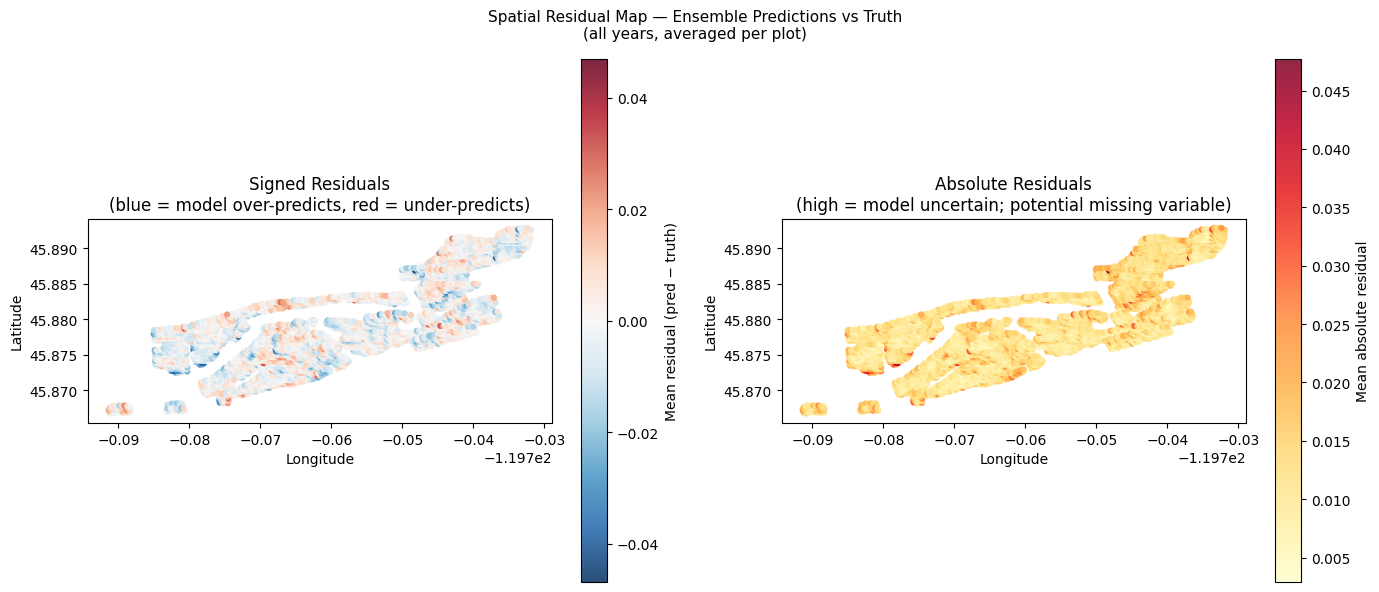

In [5]:
# --- Spatial residual map ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: signed residual (over/under prediction)
ax = axes[0]
vmax = np.abs(resid_vals).max()
norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
sc = ax.scatter(centroids_x, centroids_y, c=resid_vals, cmap='RdBu_r',
                norm=norm, s=12, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Mean residual (pred − truth)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Signed Residuals\n(blue = model over-predicts, red = under-predicts)')
ax.set_aspect('equal')

# Right: absolute residual (uncertainty map)
ax2 = axes[1]
sc2 = ax2.scatter(centroids_x, centroids_y, c=abs_resid_vals, cmap='YlOrRd',
                  s=12, alpha=0.85)
plt.colorbar(sc2, ax=ax2, label='Mean absolute residual')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Absolute Residuals\n(high = model uncertain; potential missing variable)')
ax2.set_aspect('equal')

plt.suptitle('Spatial Residual Map — Ensemble Predictions vs Truth\n(all years, averaged per plot)', fontsize=11)
plt.tight_layout()
plt.savefig('../img/spatial_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

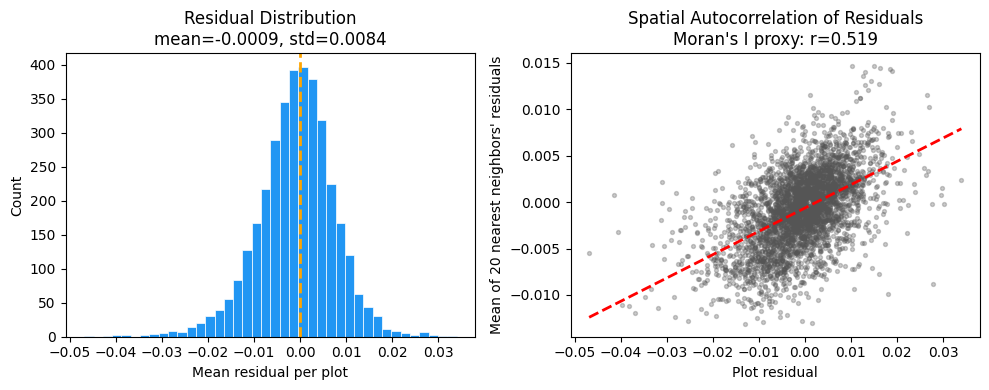

Spatial autocorrelation (Moran's I proxy): 0.5193


In [6]:
# --- Residual distribution and spatial autocorrelation check ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(resid_vals, bins=40, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='orange', linewidth=2, linestyle='--')
axes[0].set_xlabel('Mean residual per plot')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Residual Distribution\nmean={resid_vals.mean():.4f}, std={resid_vals.std():.4f}')

# Moran-style: scatter residual vs mean of 20 nearest-neighbor residuals
from numpy.linalg import norm as lnorm
coords = np.column_stack([centroids_x, centroids_y])

k = 20
spatial_lag = np.zeros(len(resid_vals))
for i in range(len(coords)):
    dists = lnorm(coords - coords[i], axis=1)
    nn_idx = np.argsort(dists)[1:k+1]
    spatial_lag[i] = resid_vals[nn_idx].mean()

axes[1].scatter(resid_vals, spatial_lag, alpha=0.3, s=8, color='#555')
m = np.polyfit(resid_vals, spatial_lag, 1)
x_line = np.linspace(resid_vals.min(), resid_vals.max(), 100)
axes[1].plot(x_line, np.polyval(m, x_line), 'r--', linewidth=2)
r_moran = np.corrcoef(resid_vals, spatial_lag)[0, 1]
axes[1].set_xlabel('Plot residual')
axes[1].set_ylabel(f'Mean of {k} nearest neighbors\' residuals')
axes[1].set_title(f'Spatial Autocorrelation of Residuals\nMoran\'s I proxy: r={r_moran:.3f}')

plt.tight_layout()
plt.savefig('../img/spatial_residuals_diag.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Spatial autocorrelation (Moran's I proxy): {r_moran:.4f}")